#機械学習の勉強　--練習問題

In [1]:
'''
#9-1
購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。

#9-2
・購入するか否かに大きな影響を与える要素を特定できる
・顧客の情報から購入するか否かを予測できる。
ゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。
'''

'\n#9-1\n購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。\n\n#9-2\n・購入するか否かに大きな影響を与える要素を特定できる\n・顧客の情報から購入するか否かを予測できる。\nゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。\n'

In [2]:
#9-3
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split

df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Bank.csv')
display(df.head(5))

display(df.isnull().sum())


,id,age,job,marital,education,default,amount,housing,loan,contact,day,month,duration,campaign,previous,y
0,1,39,blue-collar,married,secondary,no,1756.0,yes,no,cellular,3,apr,370.055237,1,0,1
1,2,51,entrepreneur,married,primary,no,1443.0,no,no,cellular,18,feb,233.998933,10,0,1
2,3,36,management,single,tertiary,no,436.0,no,no,cellular,13,apr,NaN,1,2,0
3,4,63,retired,married,secondary,no,474.0,no,no,cellular,25,jan,252.525808,1,0,0
4,5,31,management,single,tertiary,no,354.0,no,no,cellular,30,apr,NaN,1,2,0


id              0
age             0
job             0
marital         0
education       0
default         0
amount          0
housing         0
loan            0
contact         0
day             0
month           0
duration     7044
campaign        0
previous        0
y               0
dtype: int64

In [6]:
df_cols=df.columns
for col in df_cols:
    display(df[col].value_counts())

id
1        1
18069    1
18093    1
18092    1
18091    1
        ..
9040     1
9039     1
9038     1
9037     1
27128    1
Name: count, Length: 27128, dtype: int64

age
32    1232
33    1211
31    1205
35    1175
34    1129
      ... 
90       1
87       1
89       1
95       1
94       1
Name: count, Length: 77, dtype: int64

job
blue-collar      5886
management       5620
technician       4491
admin.           3085
services         2506
retired          1391
self-employed     945
entrepreneur      914
unemployed        790
housemaid         765
student           557
unknown           178
Name: count, dtype: int64

marital
married     16411
single       7662
divorced     3055
Name: count, dtype: int64

education
secondary    13882
tertiary      7959
primary       4150
unknown       1137
Name: count, dtype: int64

...

month
may    8317
jul    4136
aug    3718
jun    3204
nov    2342
apr    1755
feb    1586
jan     846
oct     439
sep     356
mar     299
dec     130
Name: count, dtype: int64

duration
370.055237    1
318.263212    1
259.134910    1
454.573894    1
380.418575    1
             ..
239.179383    1
406.563430    1
283.798189    1
242.811674    1
321.215556    1
Name: count, Length: 20084, dtype: int64

campaign
1     10555
2      7599
3      3295
4      2070
5      1021
6       762
7       445
8       319
9       195
10      161
11      115
12       96
13       80
14       56
16       43
15       42
17       37
18       32
19       30
20       25
21       23
24       14
22       14
25       11
28       11
29        9
27        9
23        9
31        8
26        6
30        5
32        4
34        4
33        4
36        3
37        2
35        2
38        2
63        1
41        1
50        1
58        1
46        1
43        1
55        1
51        1
39        1
44        1
Name: count, dtype: int64

previous
0      22146
1       1684
2       1273
3        689
4        445
5        264
6        166
7        117
8         82
9         50
10        45
11        31
13        27
12        24
15        15
14        12
19         8
17         8
16         6
20         5
27         4
22         4
23         3
21         3
29         3
25         3
24         2
18         2
275        1
55         1
38         1
41         1
51         1
40         1
28         1
Name: count, dtype: int64

y
0    18445
1     8683
Name: count, dtype: int64

In [ ]:
#欠損値を補完すべきか実験

In [ ]:
#名義尺度のダミー変数化
to_dummies=['job','marital','default','housing','loan','contact']
for col in to_dummies:
    dummied=pd.get_dummies(df[col],drop_first=True,dtype=int)
    df=pd.concat([df,dummied],axis=1)
    df=df.drop(col,axis=1)

display(df.head(5))


,id,age,education,amount,day,month,duration,campaign,previous,y,...,technician,unemployed,unknown,married,single,yes,yes,yes,sending _document,telephone
0,1,39,secondary,1756.0,3,apr,370.055237,1,0,1,...,0,0,0,1,0,0,1,0,0,0
1,2,51,primary,1443.0,18,feb,233.998933,10,0,1,...,0,0,0,1,0,0,0,0,0,0
2,3,36,tertiary,436.0,13,apr,NaN,1,2,0,...,0,0,0,0,1,0,0,0,0,0
3,4,63,secondary,474.0,25,jan,252.525808,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,31,tertiary,354.0,30,apr,NaN,1,2,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:

#順序尺度のダミー変数化
#education,monthは順序尺度

display(df['education'].unique())
display(df['month'].unique())

education_map={
    'unknown':0,
    'primary':1,
    'secondary':2,
    'tertiary':3
}
df['education']=df['education'].map(education_map)

month_map={
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12
}
df['month']=df['month'].map(month_map)

df=df.drop(['education'],axis=1)
df=df.drop(['month'],axis=1)

array(['secondary', 'primary', 'tertiary', 'unknown'], dtype=object)

array(['apr', 'feb', 'jan', 'jun', 'sep', 'may', 'aug', 'mar', 'jul',
       'nov', 'oct', 'dec'], dtype=object)

In [ ]:
#テストデータの分離
train_val,test=train_test_split(df,test_size=0.2,random_state=0)

In [ ]:
print(df.columns)
display(df.head(10))

Index(['id', 'age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'yes', 'yes', 'yes',
       'sending _document', 'telephone'],
      dtype='object')


,id,age,amount,day,duration,campaign,previous,y,blue-collar,entrepreneur,...,technician,unemployed,unknown,married,single,yes,yes,yes,sending _document,telephone
0,1,39,1756.0,3,370.055237,1,0,1,1,0,...,0,0,0,1,0,0,1,0,0,0
1,2,51,1443.0,18,233.998933,10,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
2,3,36,436.0,13,NaN,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,4,63,474.0,25,252.525808,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,31,354.0,30,NaN,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5,6,29,260.0,2,238.385368,14,0,0,1,0,...,0,0,0,0,1,0,1,0,1,0
6,7,37,52.0,6,350.269989,1,9,1,0,0,...,0,0,0,1,0,0,1,0,0,0
7,8,32,449.0,18,359.912130,1,8,0,0,0,...,1,0,0,0,1,0,1,0,0,0
8,9,31,0.0,7,292.503403,2,2,0,0,0,...,0,0,0,0,1,0,1,0,0,0
9,10,32,1815.0,10,184.903837,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
#列名のうち重複しているものを変更
df.columns=['id', 'age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'default', 'housing', 'loan',
       'sending _document', 'telephone']

In [ ]:
df.shape

(27128, 26)

<Axes: >

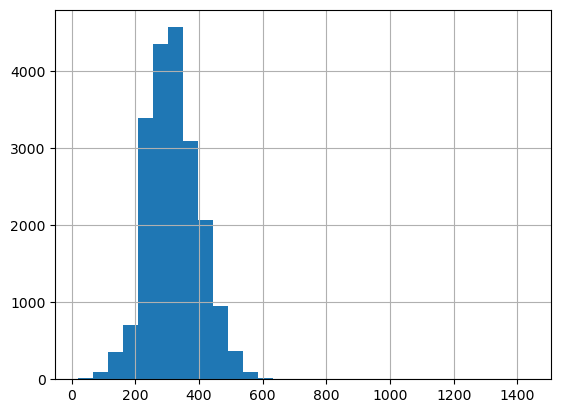

In [ ]:
#durationが欠損している人にどのような特徴があるか調べる
df['duration_missing'] = df['duration'].isna()
df['duration'].hist(bins=30)    #ヒストグラムを書く


In [ ]:
#durationが欠損している人にどのような特徴があるか調べる
display(df.groupby('duration_missing').mean(numeric_only=True).T)    #平均

duration_missing,False,True
id,13572.603764,13541.394378
age,41.635730,38.998722
amount,1304.166750,1463.969620
day,15.781169,15.877626
duration,318.222068,NaN
campaign,2.780123,2.670926
previous,0.612976,0.484952
y,0.356055,0.217490
blue-collar,0.236606,0.160988
entrepreneur,0.035750,0.027825


In [ ]:
#前のセルの結果より、欠損値を多く含むのは「student＝１」,「housing＝０」,「loan＝０」（この３列はbool）だと推察される
#これらの列の分布を調査
print(df['student'].value_counts())
print(df['housing'].value_counts())
print(df['loan'].value_counts())

student
0    26571
1      557
Name: count, dtype: int64
housing
1    15125
0    12003
Name: count, dtype: int64
loan
0    22788
1     4340
Name: count, dtype: int64


In [ ]:
'''
前のセルの結果より、「student=1」は母数が少ないため欠損値の補完に用いるのは不適。
「housing＝０」,「loan＝０」はいずれも十分に母数が多い。
２つ前のセルの結果より、loanは欠損値の有無にかかわらず低いが、housingは欠損値のある群では高く、ない群では低い。
さらに、loanの「欠損値がない群」の平均値は「欠損値がある群」の平均値の約２倍であるが、
housingの「欠損値がない群」の平均値は「欠損値がある群」の平均値の約３倍であるが、
housingのほうがより欠損値の補完に用いるのに適していると考える。
'''
#housing列でグループ化して、durationの欠損値を補完
df.groupby('housing')['duration'].mean(numeric_only=True)

housing
0    252.145680
1    349.839892
Name: duration, dtype: float64

In [ ]:
df['duration'].fillna(349.839892)
df=df.drop('duration_missing',axis=1)

In [ ]:
#特徴量の絞り込み
pd.set_option('display.max_columns', None)   # 全列表示
pd.set_option('display.width', None)         # 横幅制限を解除
display(df.corr())

,id,age,amount,day,duration,campaign,previous,y,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown,married,single,default,housing,loan,sending _document,telephone
id,1.000000,-0.005716,-0.000719,0.002974,0.007790,0.016867,-0.005425,0.001353,0.004930,0.002452,-0.007486,0.001762,0.002032,0.002136,-0.002832,0.006958,-0.000162,0.000994,-0.006645,-0.001536,0.004125,0.003077,0.002384,0.007667,0.006612,0.002542
age,-0.005716,1.000000,0.094546,-0.008518,0.207467,-0.001340,0.002946,0.093856,-0.045403,0.017521,0.084770,-0.022864,0.447656,-0.010758,-0.067086,-0.195871,-0.066126,0.001172,0.046513,0.287000,-0.426678,-0.017648,-0.188127,-0.019236,-0.018375,0.172734
amount,-0.000719,0.094546,1.000000,0.002127,-0.034113,-0.016176,0.012239,-0.009768,-0.053293,0.018849,0.002615,0.072986,0.044607,0.017433,-0.038985,0.001843,-0.019923,0.008516,0.012433,0.023229,-0.010525,-0.064810,-0.069432,-0.084882,-0.037351,0.030130
day,0.002974,-0.008518,0.002127,1.000000,-0.024676,0.164880,-0.050009,0.023500,-0.022529,0.000493,0.000194,0.017793,-0.009911,0.006658,-0.003227,-0.013439,0.029872,-0.000024,-0.014977,0.005898,-0.004687,0.007975,-0.033167,0.009938,-0.031134,0.018269
duration,0.007790,0.207467,-0.034113,-0.024676,1.000000,-0.024244,0.137363,0.275922,0.080284,0.009911,-0.039557,-0.041817,0.028337,-0.015267,0.019610,-0.108228,-0.014258,-0.040929,-0.045069,0.114176,-0.163444,0.013193,0.558301,0.371320,0.086509,0.001647
campaign,0.016867,-0.001340,-0.016176,0.164880,-0.024244,1.000000,-0.031557,0.145963,0.011072,0.001953,-0.000506,0.018882,-0.036441,0.003895,-0.003580,-0.021345,0.025561,-0.019626,0.012294,0.031635,-0.018753,0.014263,-0.020902,0.010495,0.007494,0.053009
previous,-0.005425,0.002946,0.012239,-0.050009,0.137363,-0.031557,1.000000,0.022762,-0.020051,-0.006844,-0.010539,0.013184,0.005046,-0.002959,-0.012042,0.019321,0.008296,-0.005428,-0.007512,-0.009969,0.013445,-0.016082,0.035886,-0.008316,-0.142262,0.018839
y,0.001353,0.093856,-0.009768,0.023500,0.275922,0.145963,0.022762,1.000000,0.039499,0.023846,-0.013774,-0.015368,0.023207,-0.007098,0.007611,-0.049748,-0.008601,-0.025310,-0.004868,0.056774,-0.069405,-0.020843,0.196458,0.092874,0.133751,-0.002934
blue-collar,0.004930,-0.045403,-0.053293,-0.022529,0.080284,0.011072,-0.020051,0.039499,1.000000,-0.098292,-0.089670,-0.269079,-0.122376,-0.100004,-0.167935,-0.076214,-0.234463,-0.091166,-0.042780,0.119145,-0.085707,0.014178,0.187858,0.024236,0.141028,-0.005566
entrepreneur,0.002452,0.017521,0.018849,0.000493,0.009911,0.001953,-0.006844,0.023846,-0.098292,1.000000,-0.031808,-0.095450,-0.043410,-0.035474,-0.059571,-0.027035,-0.083170,-0.032339,-0.015175,0.043077,-0.050440,0.021133,0.009628,0.034427,0.010874,-0.003247


In [ ]:
#不要な特徴量を削除(idは顧客IDであり、相関係数より顧客の特性と無関係に恣意的に決定されるものだと考えられる。)
df=df.drop('id',axis=1)

In [ ]:
#説明変数・目的変数の指定
df2=df.drop('y',axis=1)
x=df2
y=df['y']


In [ ]:
'''
x,y  前処理を終えたdf
x_train  xの訓練データ
x_val  xの検証データ
y_train  yの訓練データ
y_val  yの検証データ
test  df3のうち2割を分割したテストデータ
'''

def learn(x,y):
    #検証データの分離
    x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=0)

    for i in range(1,13):
        model=tree.DecisionTreeClassifier(max_depth=i,random_state=0)
        model.fit(x_train, y_train)
        train_score=model.score(x_val,y_val)
        print(f'決定木の深さ={i}, 検証データでの正解率={train_score}')


learn(x,y)

        

決定木の深さ=1, 検証データでの正解率=0.6983044600073719
決定木の深さ=2, 検証データでの正解率=0.717840029487652
決定木の深さ=3, 検証データでの正解率=0.7386656837449318
決定木の深さ=4, 検証データでの正解率=0.7368227054920752
決定木の深さ=5, 検証データでの正解率=0.8096203464799115
決定木の深さ=6, 検証データでの正解率=0.8203096203464799
決定木の深さ=7, 検証データでの正解率=0.8239955768521932
決定木の深さ=8, 検証データでの正解率=0.8378179137486178
決定木の深さ=9, 検証データでの正解率=0.8402137854773314
決定木の深さ=10, 検証データでの正解率=0.8311831920383339
決定木の深さ=11, 検証データでの正解率=0.8258385551050498
決定木の深さ=12, 検証データでの正解率=0.8236269812016218


In [ ]:
#決定木の深さは、実験段階では９とする。(x,y)を用いた検証データでの正解率=0.8297088094360486と比較する。
def exlearn(x,y):
    #検証データの分離
    x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=0)


    model=tree.DecisionTreeClassifier(max_depth=9,random_state=0)
    model.fit(x_train, y_train)
    train_score=model.score(x_val,y_val)

    return train_score

In [ ]:
#多項式特徴量を導入し、実験してみる
x1=x.copy()
x1['age*2']=x1['age']*2
x1=x1.drop('age',axis=1)
print(f'検証データでの正解率={exlearn(x1,y)}')

検証データでの正解率=0.8407666789531884


In [ ]:
x2=x.copy()
x2=x2.drop('age',axis=1)
for i in range(1,5):
    x2['age*i']=x['age']*i
    print(f'検証データでの正解率={exlearn(x2,y)}')

検証データでの正解率=0.8407666789531884
検証データでの正解率=0.8407666789531884
検証データでの正解率=0.8407666789531884
検証データでの正解率=0.8407666789531884


In [ ]:
#決定木なので多項式解析は有用ではない。
#相互特徴量を導入し、実験してみる。
x3=x.copy()
x3['age*amount']=x3['age']*x3['amount']
x3=x3.drop('age',axis=1)
x3=x3.drop('amount',axis=1)
print(f'検証データでの正解率={exlearn(x3,y)}')

検証データでの正解率=0.7985624769627718


In [ ]:
print(x.columns)

Index(['age', 'amount', 'day', 'duration', 'campaign', 'previous',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'default', 'housing', 'loan',
       'sending _document', 'telephone'],
      dtype='object')


In [ ]:
x_cols=['age', 'amount', 'day', 'duration', 'campaign', 'previous',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'default', 'housing', 'loan',
       'sending _document', 'telephone']

#learn(x,y)の正解率0.829よりも高い正解率を示す特徴量を探す。
#0.84以上のものを表示・
for i in range(len(x_cols)-2):
    for j in range(len(x_cols)-i-2):
       x4=x.copy()
       x4['new']=x4[x_cols[i]]*x4[x_cols[i+j+1]]
       x4=x4.drop([x_cols[i]],axis=1)
       x4=x4.drop([x_cols[i+1]],axis=1)
       if exlearn(x4,y)>=0.84:
              print(f'検証データでの正解率={exlearn(x4,y)}')
              print(f'(列は{[x_cols[i]]}と{[x_cols[i+j+1]]})'+'\n')

検証データでの正解率=0.8418724659049023
(列は['amount']と['day'])

検証データでの正解率=0.841503870254331
(列は['amount']と['previous'])

検証データでの正解率=0.842609657206045
(列は['amount']と['entrepreneur'])

検証データでの正解率=0.8435311463324733
(列は['amount']と['housemaid'])

検証データでの正解率=0.8424253593807594
(列は['amount']と['management'])

検証データでの正解率=0.8424253593807594
(列は['amount']と['retired'])

検証データでの正解率=0.840950976778474
(列は['amount']と['self-employed'])

検証データでの正解率=0.8413195724290453
(列は['amount']と['services'])

検証データでの正解率=0.8422410615554736
(列は['amount']と['student'])

検証データでの正解率=0.841503870254331
(列は['amount']と['technician'])

検証データでの正解率=0.841503870254331
(列は['amount']と['unemployed'])

検証データでの正解率=0.8418724659049023
(列は['amount']と['unknown'])

検証データでの正解率=0.8400294876520457
(列は['amount']と['married'])

検証データでの正解率=0.842056763730188
(列は['amount']と['single'])

検証データでの正解率=0.8431625506819019
(列は['amount']と['default'])

検証データでの正解率=0.841503870254331
(列は['amount']と['housing'])

検証データでの正解率=0.840950976778474
(列は['amount']と['loan'])

検証データで

In [ ]:
#多項式特徴量、相互特徴量では精度改善の見込みが低い。
for col in x_cols:
    x5=x.copy()
    x5=x5.drop([col],axis=1)
    print(f'検証データでの正解率={exlearn(x5,y)}')